Epoch 1/100


/Users/vroni/miniconda3/envs/ParkData/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



53/53 - 11s - 198ms/step - loss: 0.0420 - val_loss: 0.0327
Epoch 2/100
53/53 - 8s - 145ms/step - loss: 0.0199 - val_loss: 0.0267
Epoch 3/100
53/53 - 8s - 147ms/step - loss: 0.0160 - val_loss: 0.0227
Epoch 4/100
53/53 - 8s - 143ms/step - loss: 0.0146 - val_loss: 0.0208
Epoch 5/100
53/53 - 8s - 144ms/step - loss: 0.0131 - val_loss: 0.0198
Epoch 6/100
53/53 - 8s - 144ms/step - loss: 0.0122 - val_loss: 0.0190
Epoch 7/100
53/53 - 8s - 156ms/step - loss: 0.0114 - val_loss: 0.0179
Epoch 8/100
53/53 - 9s - 176ms/step - loss: 0.0104 - val_loss: 0.0158
Epoch 9/100
53/53 - 10s - 183ms/step - loss: 0.0091 - val_loss: 0.0145
Epoch 10/100
53/53 - 10s - 187ms/step - loss: 0.0085 - val_loss: 0.0132
Epoch 11/100
53/53 - 10s - 187ms/step - loss: 0.0076 - val_loss: 0.0125
Epoch 12/100
53/53 - 10s - 186ms/step - loss: 0.0070 - val_loss: 0.0108
Epoch 13/100
53/53 - 10s - 184ms/step - loss: 0.0063 - val_loss: 0.0109
Epoch 14/100
53/53 - 9s - 179ms/step - loss: 0.0060 - val_loss: 0.0100
Epoch 15/100
53/53 - 

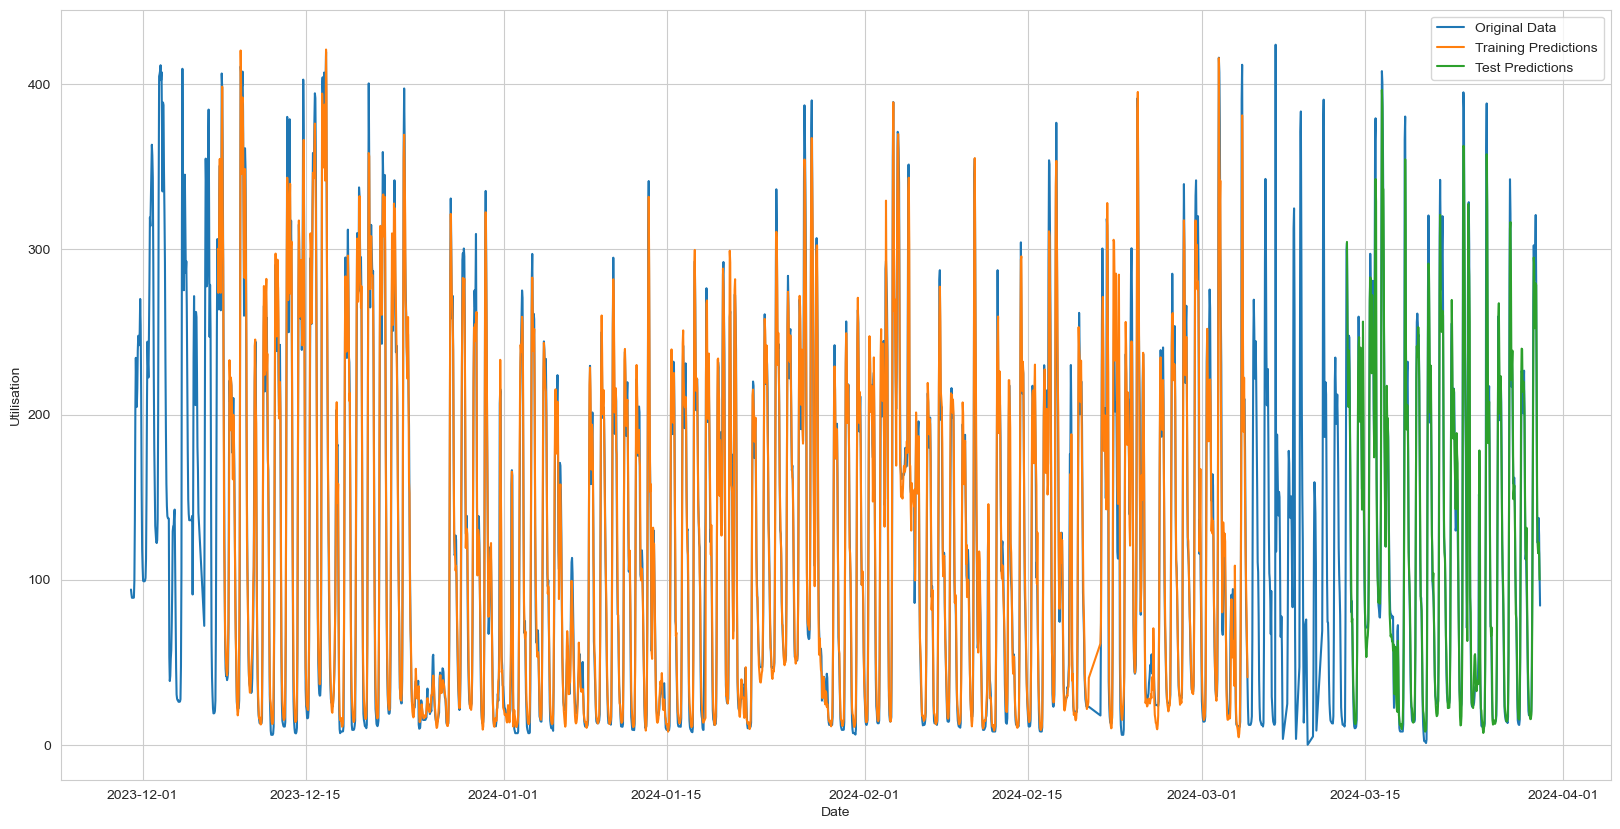

In [289]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.optimizers import Adam
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


# convert an array of values into a dataset matrix
def create_dataset(dataset, window=168):
	dataX = []
	dataY = []
	for i in range(len(dataset)-window-1):
		dataX.append(dataset[i:(i+window), :])
		dataY.append(dataset[i + window, 0])
	return np.array(dataX), np.array(dataY)

tf.random.set_seed(7)
data = pd.read_csv('./data/out_hourly.csv')
dataset = pd.DataFrame(data)
dataset = dataset.sort_values('timestamp')
dataset['timestamp'] = pd.to_datetime(dataset['timestamp'])
start_date = pd.to_datetime('2023-11-30')
end_date = pd.to_datetime('2024-03-30')
dataset = dataset[(dataset['timestamp'] >= start_date) & (dataset['timestamp'] <= end_date)]
dataset['hour'] = dataset['timestamp'].dt.hour
dataset['dayOfWeek'] = dataset['timestamp'].dt.dayofweek
dataset['event_name'] = dataset['event_name'].apply(lambda x: 1 if isinstance(x, str) and x != "0" else 0)
dataset['holiday'] = dataset['holiday'].apply(lambda x: 1 if pd.notna(x) and isinstance(x, str) and x.strip() != "" else 0)

dataset.set_index('timestamp', inplace=True)
dates = dataset.index
columns_needed = ['value', 'rhum', 'tsun', 'event_name', 'holiday', 'hour', 'dayOfWeek']
dataset = dataset[[col for col in columns_needed if col in dataset.columns]]
if dataset['tsun'].isna().any():
    dataset['tsun'] = dataset['tsun'].fillna(0)
#dataset = np.array(dataset)
dataset['value'] = dataset['value'].astype('float32')

start_dataset = dataset.copy()

scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)


# split into train and test sets
train_size = int(len(dataset) * 0.80)
test_size = len(dataset) - train_size
train_df, test_df = dataset[0:train_size], dataset[train_size:len(dataset)]
train = train_df
test = test_df

# reshape into X=t and Y=t+1
window = 168
trainX, trainY = create_dataset(train, window)

testX, testY = create_dataset(test, window)

prediction_data = testX.copy()

# create and fit the LSTM network
model = Sequential()
model.add(LSTM(168, return_sequences=True, input_shape=(trainX.shape[1], trainX.shape[2])))
model.add(Dropout(0.2))
model.add(Dense(8, activation = 'relu'))
model.add(LSTM(168))
model.add(Dropout(0.2))
model.add(Dense(1, activation = 'linear'))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=32, verbose=2, validation_split=0.2)


# make predictions
trainPredict = model.predict(trainX)
trainPredict = np.clip(trainPredict, 0, 429)
print(trainPredict.shape)
testPredict = model.predict(testX)
testPredict = np.clip(testPredict, 0, 429)


trainPredict = scaler.inverse_transform(np.concatenate((trainPredict, np.ones((len(trainPredict), 6))), axis=1))[:,0]
trainY = scaler.inverse_transform(np.concatenate((trainY.reshape(-1, 1), np.ones((len(trainY), 6))), axis=1)
)[:, 0]
testPredict = scaler.inverse_transform(np.concatenate((testPredict, np.ones((len(testPredict), 6))), axis=1))[:,0]
testY =scaler.inverse_transform(np.concatenate((testY.reshape(-1, 1), np.ones((len(testY), 6))), axis=1)
)[:, 0]

# calculate root mean squared error
trainScore = np.sqrt(mean_squared_error(trainY, trainPredict))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY, testPredict))
print('Test Score: %.2f RMSE' % (testScore))

trainPredictPlot = np.empty_like(dataset[:, 0])
trainPredictPlot[:] = np.nan
trainPredictPlot[window:len(trainPredict)+window] = trainPredict
# shift test predictions for plotting
testPredictPlot = np.empty_like(dataset[:, 0])
testPredictPlot[:] = np.nan
testPredictPlot[len(trainPredict)+(window*2)+1:len(dataset)-1] = testPredict
# plot baseline and predictions
plt.figure(figsize=(20, 10))
dataset = scaler.inverse_transform(dataset)
plt.plot(dates, dataset[:, 0] , label='Original Data')
plt.plot(dates, trainPredictPlot, label='Training Predictions')
plt.plot(dates, testPredictPlot, label='Test Predictions')
plt.xlabel('Date')
plt.ylabel('Utilisation')
plt.legend()
plt.show()


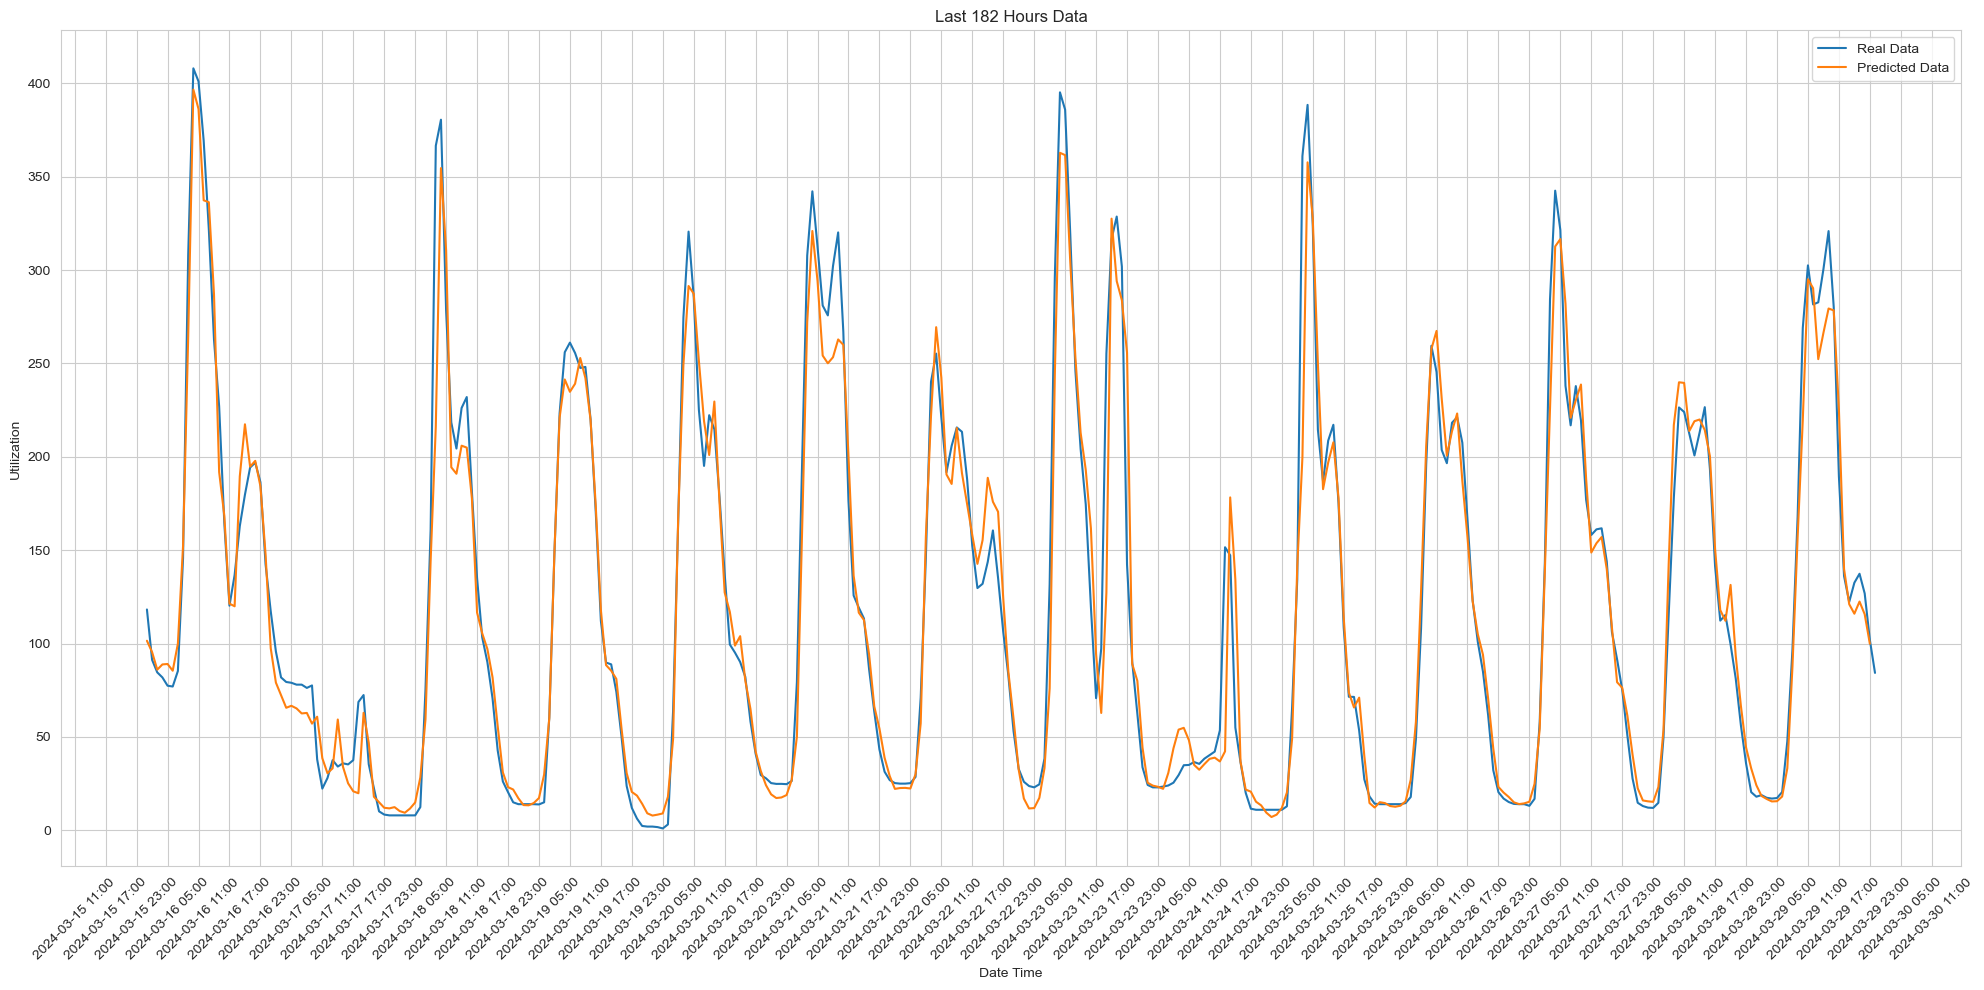

In [290]:
import matplotlib.dates as mdates
last_48 = testPredictPlot[-336:]
last_48 = np.clip(last_48, 0, 429)
last_48_dates = dates[-336:]
last_48_dataset = dataset[-336:, :]

plt.figure(figsize=(20, 10))
plt.plot(last_48_dates, last_48_dataset[:,0], label='Real Data')
plt.plot(last_48_dates, last_48, label='Predicted Data')
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.xlabel('Date Time')
plt.ylabel('Utilization')
plt.title('Last 182 Hours Data')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [288]:
import plotly.graph_objects as go

# Create figure
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=dates,
        y=dataset[:,0],
        name='True Values',
        line=dict(color='blue')
    )
)

fig.add_trace(
    go.Scatter(
        x=dates,
        y=testPredictPlot,
        name='Predictions',
        line=dict(color='red')
    )
)
fig.add_trace(
    go.Scatter(
        x=dates,
        y=trainPredictPlot,
        name='Predictions',
        line=dict(color='green')
    )
)
# Set title
fig.update_layout(
    title_text="Time series with range slider and selectors"
)

# Add range slider
fig.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1m", step="month", stepmode="backward"),
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(count=1, label="YTD", step="year", stepmode="todate"),
                dict(count=1, label="1y", step="year", stepmode="backward"),
                dict(step="all")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    ),
    autosize=False,
    width=1400,
    height=800
)
fig.show()


13/13 - 1s - 56ms/step
              timestamp  holiday  tavg  tmin  tmax  prcp_x  snow  wspd_x  \
0   2024-03-31 00:00:00        0  12.0   4.9  19.6     0.3   0.0     9.2   
1   2024-03-31 01:00:00        0  12.0   4.9  19.6     0.3   0.0     9.2   
2   2024-03-31 02:00:00        0   0.0   0.0   0.0     0.0   0.0     0.0   
3   2024-03-31 03:00:00        0  12.0   4.9  19.6     0.3   0.0     9.2   
4   2024-03-31 04:00:00        0  12.0   4.9  19.6     0.3   0.0     9.2   
..                  ...      ...   ...   ...   ...     ...   ...     ...   
716 2024-04-29 20:00:00        0  13.3   5.4  22.1     0.0   0.0     2.9   
717 2024-04-29 21:00:00        0  13.3   5.4  22.1     0.0   0.0     2.9   
718 2024-04-29 22:00:00        0  13.3   5.4  22.1     0.0   0.0     2.9   
719 2024-04-29 23:00:00        0  13.3   5.4  22.1     0.0   0.0     2.9   
720 2024-04-30 00:00:00        0  17.3   9.2  25.3     0.0   0.0     3.5   

     wpgt_x  pres_x  ...  wspd_y  wpgt_y  pres_y  tsun  event_na

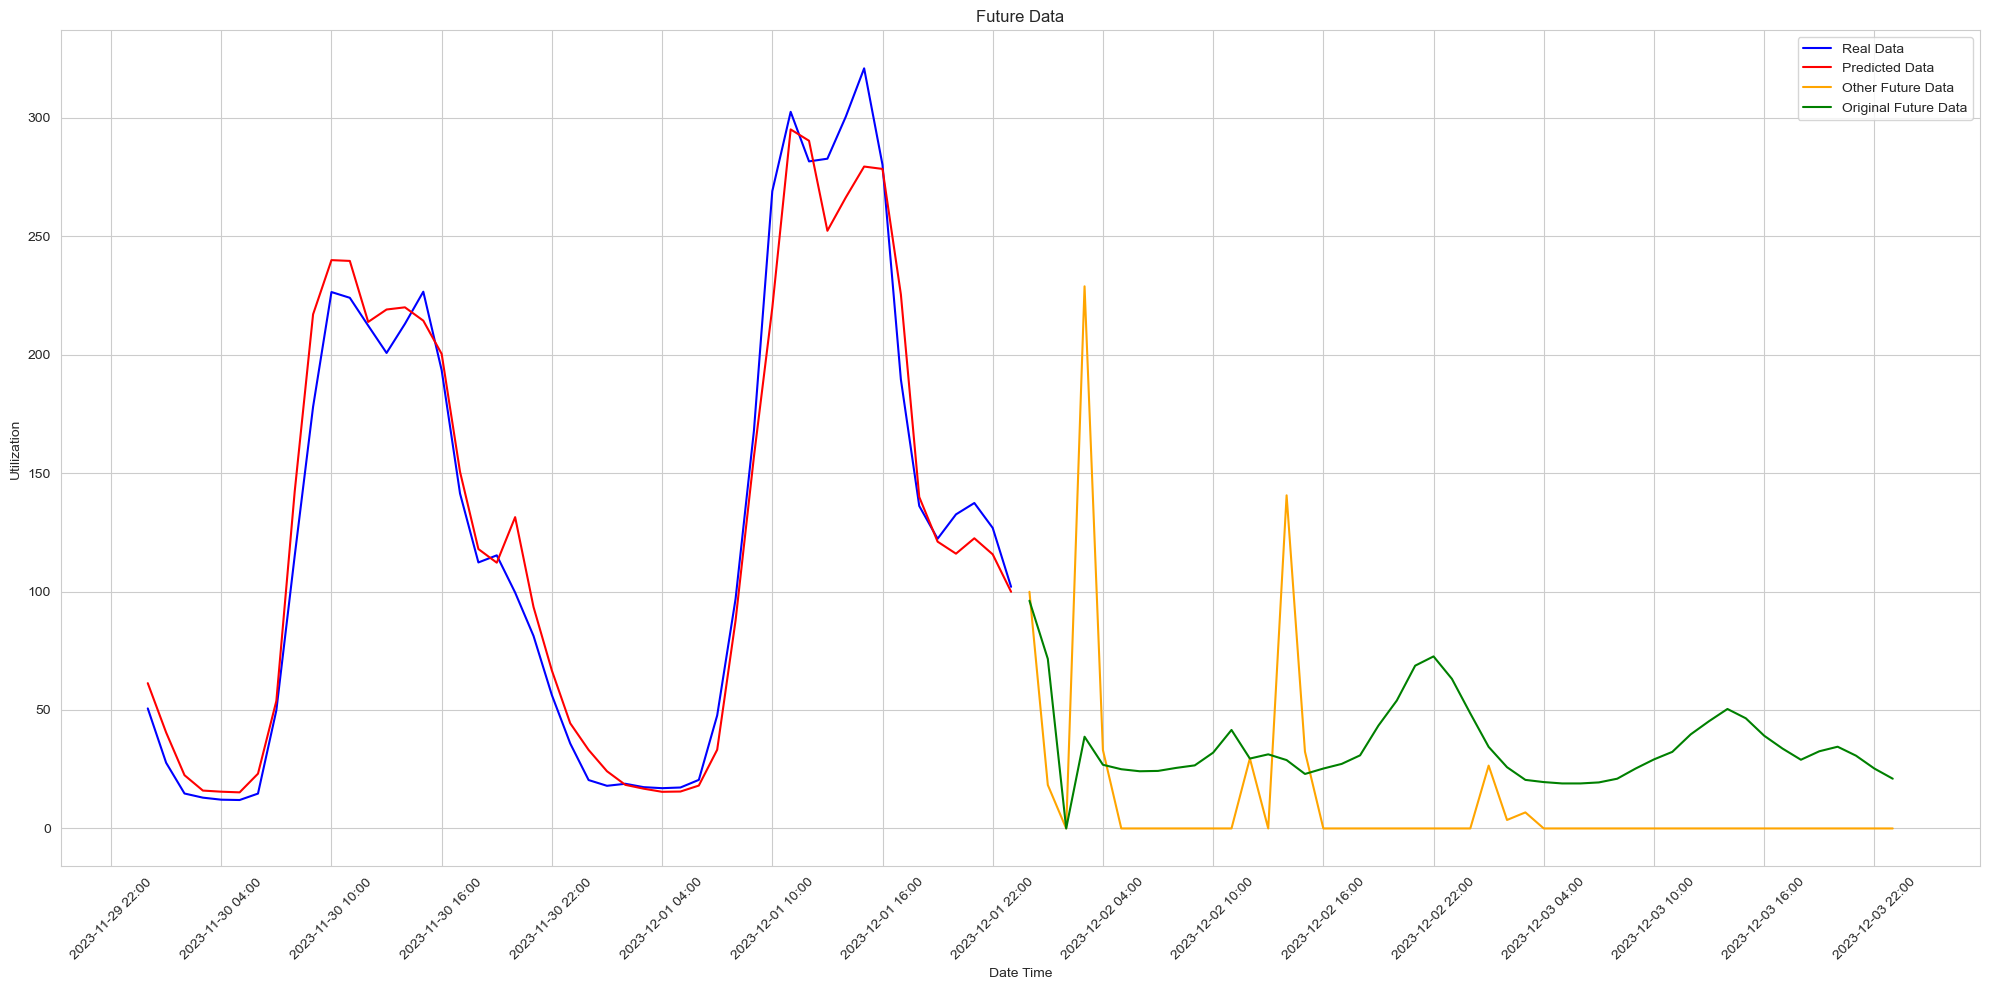

In [352]:
prediction_dataX, prediction_dataY = create_dataset(test, window)
copy = prediction_dataX.copy()
yhat = model.predict(prediction_dataX, verbose=2)

control_data = pd.DataFrame(data)
control_data['timestamp'] = pd.to_datetime(control_data['timestamp'])
start_date = pd.to_datetime('2024-03-31')
end_date = pd.to_datetime('2024-04-30')
control_data = control_data[(control_data['timestamp'] >= start_date) & (control_data['timestamp'] <= end_date)]
control_data['hour'] = control_data['timestamp'].dt.hour
control_data['dayOfWeek'] = control_data['timestamp'].dt.dayofweek
control_data.set_index('timestamp', inplace=True)
control_data = control_data.asfreq('H')
mask = (control_data['dayOfWeek'].isna()) | (control_data['dayOfWeek'] == 0)
control_data.loc[mask, 'dayOfWeek'] = control_data.index[mask].dayofweek
control_data['hour'] = control_data['hour'].interpolate(method='time')
control_data.reset_index(inplace=True)
control_data['event_name'] = control_data['event_name'].apply(lambda x: 1 if isinstance(x, str) and x != "0" else 0)
control_data['holiday'] = control_data['holiday'].apply(lambda x: 1 if pd.notna(x) and isinstance(x, str) and x.strip() != "" else 0)
control_data = control_data.fillna(0)
print(control_data)


current_seq = prediction_dataX[-1].copy()  # shape: (168, 7)
last_timestamp = start_dataset.index[-1]
future_steps = 48

predicted_values = []

for i in range(future_steps):
    # Modellvorhersage (für value)
    input_seq = np.expand_dims(current_seq, axis=0)  # (1, 168, 7)
    pred = model.predict(input_seq, verbose=0)
    pred_value = pred.squeeze()  # float

    predicted_values.append(pred_value)
    future_features = control_data.loc[i, ['rhum', 'tsun', 'event_name', 'holiday', 'hour', 'dayOfWeek']]
    # Zeit simulieren
    #last_timestamp += pd.Timedelta(hours=1)
    hour = future_features['hour']
    day_of_week = future_features['dayOfWeek']

    rhum = future_features['rhum']
    tsun = future_features['tsun']
    event_name = future_features['event_name']
    holiday = future_features['holiday']

    # Neue Zeile aufbauen: value + restliche Features
    next_step = np.array([pred_value, rhum, tsun, event_name, holiday, hour, day_of_week]).reshape(1, 7)

    # Fenster verschieben
    current_seq = np.vstack((current_seq[1:], next_step))

future = scaler.inverse_transform(np.concatenate((yhat, np.ones((len(yhat), 6))), axis=1))[:,0]
tested = scaler.inverse_transform(np.concatenate((prediction_dataY.reshape(-1, 1), np.ones((len(prediction_dataY), 6))), axis=1))[:,0]
final_values = scaler.inverse_transform(np.concatenate(
    (np.array(predicted_values).reshape(-1, 1), np.ones((future_steps, 6))),
    axis=1
))[:, 0]
final_values = np.clip(final_values, 0, 429)
hist_axis = len(tested[-48:])
forecast_axis = hist_axis + len(final_values)
last_data = control_data['value'].values[:len(final_values)]

all_dates = dates.union(control_data.index[:len(final_values)])

plt.figure(figsize=(20, 10))
# Historie (Real Data)
plt.plot(all_dates[:hist_axis], tested[-48:], color='blue', label='Real Data')
# Historie (Predicted Data)
plt.plot(all_dates[:hist_axis], future[-48:], color='red', label='Predicted Data')
# Prognose (Other Future Data)
plt.plot(all_dates[hist_axis:forecast_axis], final_values.tolist(), color='orange', label='Other Future Data')
# Prognose (Original Future Data)
plt.plot(all_dates[hist_axis:forecast_axis], last_data.tolist(), color='green', label='Original Future Data')
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.xlabel('Date Time')
plt.ylabel('Utilization')
plt.title('Future Data')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()